In [12]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

In [13]:
df= pd.read_csv("loan_prediction.csv")

In [14]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [16]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

<Axes: >

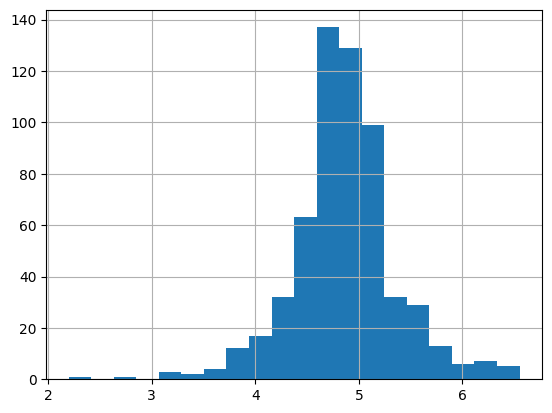

In [17]:
df['loanAmount_log'] = np.log(df['LoanAmount'])
df['loanAmount_log'].hist(bins=20)

In [18]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'loanAmount_log'],
      dtype='object')


In [19]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
loanAmount_log       22
dtype: int64

In [20]:
df['Gender'].fillna(df['Gender'].mode()[0],inplace = True)
df['Married'].fillna(df['Married'].mode()[0],inplace = True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0],inplace = True)
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace = True)

df.LoanAmount = df.LoanAmount.fillna(df.LoanAmount.mean())
df.loanAmount_log = df.loanAmount_log.fillna(df.loanAmount_log.mean())

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0],inplace = True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0],inplace = True)

df.isnull().sum()


C:\Users\Asus\AppData\Local\Temp\ipykernel_5924\1821822132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0],inplace = True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_5924\1821822132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
loanAmount_log       0
dtype: int64

In [21]:
x = df.iloc[:, [1,2,3,4,9,10,13]].values
y = df.iloc[:, 12].values

x


array([['Male', 'No', '0', ..., 360.0, 1.0, 4.857444178729352],
       ['Male', 'Yes', '1', ..., 360.0, 1.0, 4.852030263919617],
       ['Male', 'Yes', '0', ..., 360.0, 1.0, 4.189654742026425],
       ...,
       ['Male', 'Yes', '1', ..., 360.0, 1.0, 5.53338948872752],
       ['Male', 'Yes', '2', ..., 360.0, 1.0, 5.231108616854587],
       ['Female', 'No', '0', ..., 360.0, 0.0, 4.890349128221754]],
      shape=(614, 7), dtype=object)

In [22]:
y

array(['Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y',
       'Y', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N',
       'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'N',
       'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N',
       'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N

In [23]:
print(" percentage of Missing gender Is %2f%%" %((df['Gender'].isnull().sum()/df.shape[0])*100))

 percentage of Missing gender Is 0.000000%


Number Of People Who Take Loan As Group By Gender :
Gender
Male      502
Female    112
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_5924\3287431632.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender',data=df, palette= 'Set1')


<Axes: xlabel='Gender', ylabel='count'>

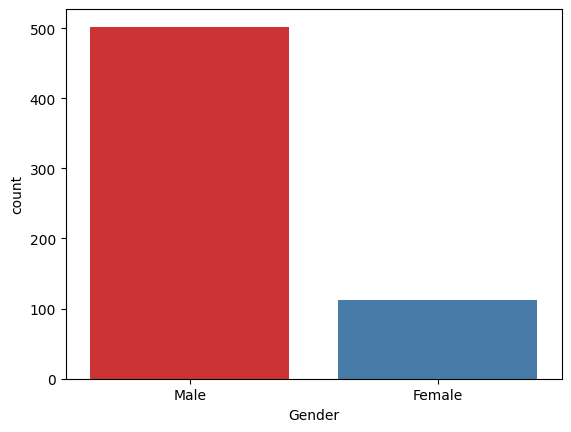

In [24]:
print("Number Of People Who Take Loan As Group By Gender :")
print(df['Gender'].value_counts())
sns.countplot(x='Gender',data=df, palette= 'Set1')

Number Of People Who Take Loan As Group By Marital Status :
Married
Yes    401
No     213
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_5924\577894889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Married',data=df, palette= 'Set1')


<Axes: xlabel='Married', ylabel='count'>

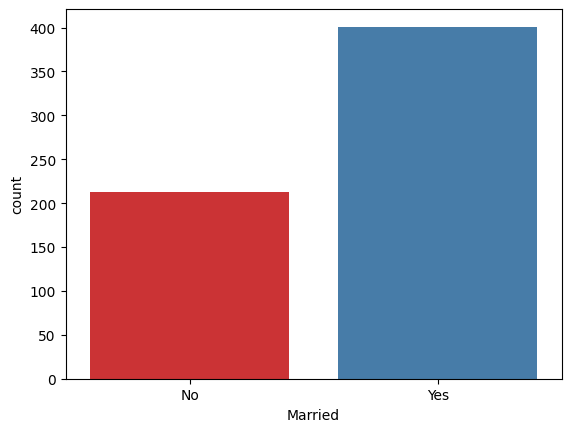

In [25]:
print("Number Of People Who Take Loan As Group By Marital Status :")
print(df['Married'].value_counts())
sns.countplot(x='Married',data=df, palette= 'Set1')

Number Of People Who Take Loan As Group By Dependents :
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_5924\1712844675.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dependents',data=df, palette= 'Set1')


<Axes: xlabel='Dependents', ylabel='count'>

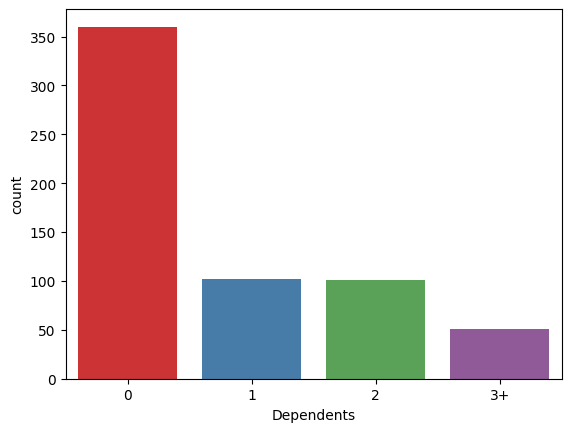

In [26]:
print("Number Of People Who Take Loan As Group By Dependents :")
print(df['Dependents'].value_counts())
sns.countplot(x='Dependents',data=df, palette= 'Set1')

Number Of People Who Take Loan As Group By Self_Employed :
Self_Employed
No     532
Yes     82
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_5924\1478565128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Self_Employed',data=df, palette= 'Set1')


<Axes: xlabel='Self_Employed', ylabel='count'>

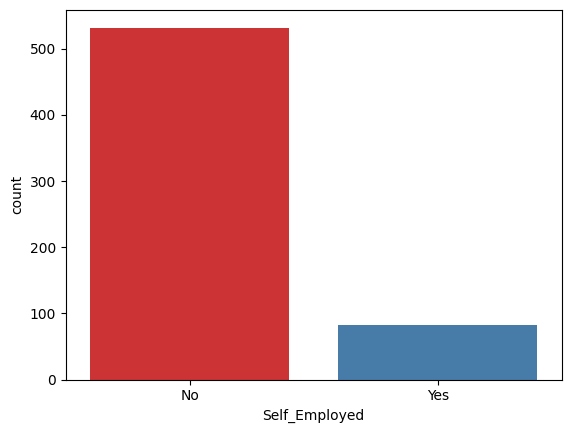

In [27]:
print("Number Of People Who Take Loan As Group By Self_Employed :")
print(df['Self_Employed'].value_counts())
sns.countplot(x='Self_Employed',data=df, palette= 'Set1')

Number Of People Who Take Loan As Group By LoanAmount :
LoanAmount
146.412162    22
120.000000    20
110.000000    17
100.000000    15
187.000000    12
              ..
292.000000     1
142.000000     1
350.000000     1
496.000000     1
253.000000     1
Name: count, Length: 204, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_5924\3037643880.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LoanAmount',data=df, palette= 'Set1')


<Axes: xlabel='LoanAmount', ylabel='count'>

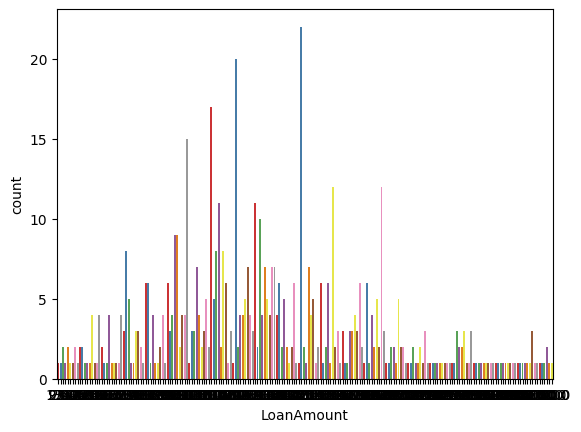

In [28]:
print("Number Of People Who Take Loan As Group By LoanAmount :")
print(df['LoanAmount'].value_counts())
sns.countplot(x='LoanAmount',data=df, palette= 'Set1')

Number Of People Who Take Loan As Group By Credit_History :
Credit_History
1.0    525
0.0     89
Name: count, dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_5924\390606712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_History',data=df, palette= 'Set1')


<Axes: xlabel='Credit_History', ylabel='count'>

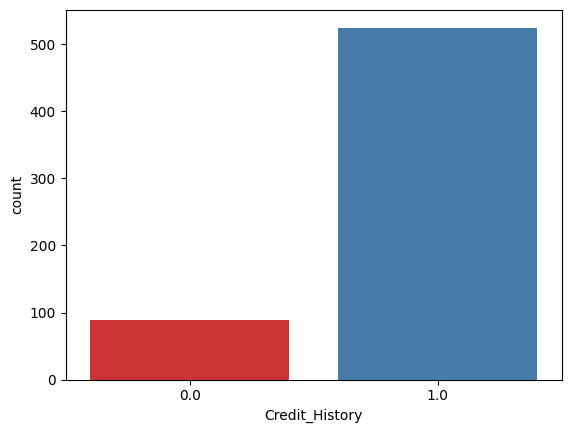

In [29]:
print("Number Of People Who Take Loan As Group By Credit_History :")
print(df['Credit_History'].value_counts())
sns.countplot(x='Credit_History',data=df, palette= 'Set1')

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 0)

from sklearn.preprocessing import LabelEncoder
Labelencoder_x = LabelEncoder()

In [31]:
for i in range(0, 5):
    X_train[:,i]= Labelencoder_x.fit_transform(X_train[:,i])
    X_train[:,6] = Labelencoder_x.fit_transform(X_train[:,6])

    X_train

In [32]:
X_train

array([[1, 1, 0, ..., 7, 1.0, 81],
       [1, 0, 1, ..., 7, 1.0, 131],
       [1, 1, 0, ..., 7, 0.0, 98],
       ...,
       [1, 1, 3, ..., 7, 1.0, 132],
       [1, 1, 0, ..., 7, 1.0, 108],
       [0, 1, 0, ..., 7, 1.0, 122]], shape=(491, 7), dtype=object)

In [33]:
Labelencoder_y = LabelEncoder()
y_train = Labelencoder_y.fit_transform(y_train)

In [34]:
y_train

array([1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,

In [35]:
for i in range(0,5):
    X_test[:,i] = Labelencoder_x.fit_transform(X_test[:,i])
    X_test[:,6] = Labelencoder_x.fit_transform(X_test[:,6])
    

In [36]:
X_test

array([[1, 0, 0, 0, 5, 1.0, 10],
       [0, 0, 0, 0, 5, 1.0, 24],
       [1, 1, 0, 0, 5, 1.0, 71],
       [1, 1, 0, 0, 5, 1.0, 22],
       [1, 1, 2, 0, 5, 1.0, 16],
       [1, 1, 0, 1, 3, 0.0, 48],
       [1, 1, 3, 0, 3, 1.0, 45],
       [1, 0, 0, 0, 5, 1.0, 72],
       [1, 0, 0, 0, 5, 0.0, 30],
       [1, 1, 0, 0, 5, 1.0, 33],
       [0, 0, 0, 0, 5, 1.0, 10],
       [1, 1, 1, 0, 5, 1.0, 14],
       [0, 0, 0, 0, 5, 1.0, 68],
       [1, 1, 2, 0, 5, 1.0, 65],
       [1, 1, 0, 0, 5, 1.0, 15],
       [1, 1, 1, 0, 5, 1.0, 3],
       [1, 0, 1, 1, 5, 1.0, 58],
       [1, 0, 0, 1, 5, 1.0, 36],
       [0, 0, 0, 0, 5, 1.0, 13],
       [1, 1, 0, 1, 5, 0.0, 55],
       [0, 1, 0, 0, 5, 0.0, 28],
       [1, 1, 0, 0, 5, 1.0, 43],
       [1, 1, 2, 0, 5, 1.0, 21],
       [1, 1, 2, 0, 5, 1.0, 48],
       [1, 1, 0, 0, 5, 1.0, 2],
       [1, 1, 1, 0, 5, 1.0, 66],
       [1, 0, 0, 0, 5, 1.0, 57],
       [1, 1, 0, 0, 5, 1.0, 57],
       [1, 1, 3, 0, 5, 0.0, 33],
       [0, 0, 0, 0, 5, 0.0, 18],
       [1, 1

In [37]:
Labelencoder_y = LabelEncoder()
y_test = Labelencoder_y.fit_transform(y_test)

In [38]:
y_test

array([1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1])

In [39]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train = ss.fit_transform(X_train)   # ✅ Fit only on training data
X_test = ss.transform(X_test)         # ✅ Only transform test data

In [40]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
from sklearn import metrics
y_pred = rf_clf.predict(X_test)
print(" Accuracy of Random Forest is" , metrics.accuracy_score(y_pred, y_test))

y_pred


 Accuracy of Random Forest is 0.8211382113821138


array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1])

In [42]:
from sklearn.naive_bayes import GaussianNB
nb_clf = GaussianNB()
nb_clf.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [43]:

y_pred = nb_clf.predict(X_test)
print(" Accuracy of Naive Bayes is" , metrics.accuracy_score(y_pred, y_test))

y_pred

 Accuracy of Naive Bayes is 0.8292682926829268


array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1])

In [44]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
y_pred = dt_clf.predict(X_test)
print(" Accuracy of Decision Tree is ", metrics.accuracy_score(y_pred,y_test))
y_pred

 Accuracy of Decision Tree is  0.6178861788617886


array([0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0])

In [46]:
from sklearn.neighbors import KNeighborsClassifier
kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [47]:
y_pred = kn_clf.predict(X_test)
print(" Accuracy of Kneighbors Classifier is ", metrics.accuracy_score(y_pred,y_test))
y_pred

 Accuracy of Kneighbors Classifier is  0.7886178861788617


array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1])

In [56]:
import numpy as np

print("===== Loan Approval Prediction =====")

gender = int(input("Gender (1=Male, 0=Female): "))
married = int(input("Married (1=Yes, 0=No): "))
education = int(input("Education (1=Graduate, 0=Not Graduate): "))
app_income = float(input("Applicant Income: "))
loan_amount = float(input("Loan Amount: "))
credit_history = int(input("Credit History (1=Good, 0=Bad): "))
property_area = int(input("Property Area (0=Rural, 1=Semiurban, 2=Urban): "))

# Arrange in SAME ORDER as training
new_data = np.array([[ 
    gender,
    married,
    education,
    app_income,
    loan_amount,
    credit_history,
    property_area
]])


===== Loan Approval Prediction =====


Gender (1=Male, 0=Female):  0
Married (1=Yes, 0=No):  0
Education (1=Graduate, 0=Not Graduate):  1
Applicant Income:  20000
Loan Amount:  35000
Credit History (1=Good, 0=Bad):  0
Property Area (0=Rural, 1=Semiurban, 2=Urban):  1


In [57]:

# Convert LoanAmount to log (same as training)
loan_amount_log = math.log(loan_amount)

In [58]:

# Scale input
new_data_scaled = ss.fit_transform(new_data)

In [59]:
from sklearn.linear_model import LogisticRegression

# Train model
classifier = LogisticRegression()
classifier.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [60]:
# Predict
prediction = classifier.predict(new_data_scaled)

if prediction[0] == 1:
    print("\n✅ Loan Approved")
else:
    print("\n❌ Loan Rejected")


✅ Loan Approved


In [61]:
import numpy as np

print("===== Loan Approval Prediction =====")

gender = int(input("Gender (1=Male, 0=Female): "))
married = int(input("Married (1=Yes, 0=No): "))
education = int(input("Education (1=Graduate, 0=Not Graduate): "))
app_income = float(input("Applicant Income: "))
loan_amount = float(input("Loan Amount: "))
credit_history = int(input("Credit History (1=Good, 0=Bad): "))
property_area = int(input("Property Area (0=Rural, 1=Semiurban, 2=Urban): "))

# Arrange in SAME ORDER as training
new_data = np.array([[ 
    gender,
    married,
    education,
    app_income,
    loan_amount,
    credit_history,
    property_area
]])

# Scale using SAME scaler used during training
new_data_scaled = ss.transform(new_data)

# Predict
prediction = classifier.predict(new_data_scaled)

if prediction[0] == 1:
    print("\n✅ Loan Approved")
else:
    print("\n❌ Loan Rejected")

===== Loan Approval Prediction =====


Gender (1=Male, 0=Female):  1
Married (1=Yes, 0=No):  1
Education (1=Graduate, 0=Not Graduate):  0
Applicant Income:  10000
Loan Amount:  50000
Credit History (1=Good, 0=Bad):  0
Property Area (0=Rural, 1=Semiurban, 2=Urban):  1



✅ Loan Approved


In [62]:
import numpy as np

print("===== Loan Approval Prediction =====")

gender = int(input("Gender (1=Male, 0=Female): "))
married = int(input("Married (1=Yes, 0=No): "))
education = int(input("Education (1=Graduate, 0=Not Graduate): "))
app_income = float(input("Applicant Income: "))
loan_amount = float(input("Loan Amount: "))
credit_history = int(input("Credit History (1=Good, 0=Bad): "))
property_area = int(input("Property Area (0=Rural, 1=Semiurban, 2=Urban): "))

# Arrange in SAME ORDER as training
new_data = np.array([[ 
    gender,
    married,
    education,
    app_income,
    loan_amount,
    credit_history,
    property_area
]])

# Scale using SAME scaler used during training
new_data_scaled = ss.transform(new_data)

# Predict
prediction = classifier.predict(new_data_scaled)

if prediction[0] == 1:
    print("\n✅ Loan Approved")
else:
    print("\n❌ Loan Rejected")

===== Loan Approval Prediction =====


Gender (1=Male, 0=Female):  1
Married (1=Yes, 0=No):  0
Education (1=Graduate, 0=Not Graduate):  0
Applicant Income:  1000
Loan Amount:  900000
Credit History (1=Good, 0=Bad):  0
Property Area (0=Rural, 1=Semiurban, 2=Urban):  0



❌ Loan Rejected
